<a href="https://colab.research.google.com/github/lakkireddylahari-bot/data-science-learning/blob/main/website.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/insurance_data.csv")

In [3]:
df

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1
5,56,1
6,55,0
7,60,1
8,62,1
9,61,1


In [5]:
df.isnull().sum()

,0
age,0
bought_insurance,0


In [6]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
5,False
6,False
7,False
8,False
9,False


In [7]:
df.corr()

,age,bought_insurance
age,1.000000,0.732395
bought_insurance,0.732395,1.000000


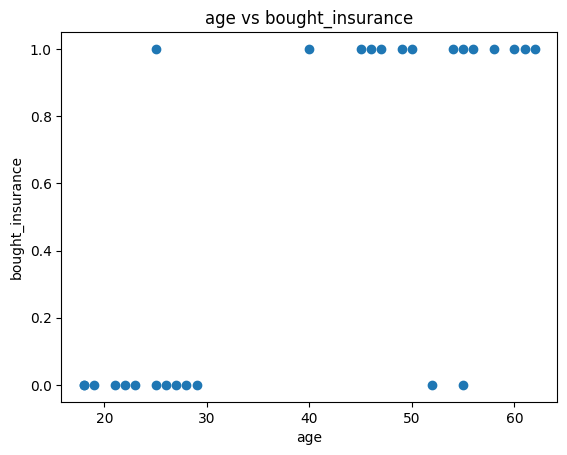

In [8]:
plt.scatter(df.age, df.bought_insurance)
plt.xlabel("age")
plt.ylabel("bought_insurance")
plt.title("age vs bought_insurance")
plt.show()

In [9]:
X = df[["age"]]
Y = df[["bought_insurance"]]
print(X)
print(Y)

    age
0    22
1    25
2    47
3    52
4    46
5    56
6    55
7    60
8    62
9    61
10   18
11   28
12   27
13   29
14   49
15   55
16   25
17   58
18   19
19   18
20   21
21   26
22   40
23   45
24   50
25   54
26   23
    bought_insurance
0                  0
1                  0
2                  1
3                  0
4                  1
5                  1
6                  0
7                  1
8                  1
9                  1
10                 0
11                 0
12                 0
13                 0
14                 1
15                 1
16                 1
17                 1
18                 0
19                 0
20                 0
21                 0
22                 1
23                 1
24                 1
25                 1
26                 0


In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )
print(X_train)
print(X_test)
print(Y_train)
print(Y_test)

    age
16   25
17   58
12   27
24   50
1    25
4    46
5    56
2    47
15   55
22   40
3    52
25   54
23   45
18   19
26   23
20   21
7    60
10   18
14   49
19   18
6    55
    age
8    62
13   29
9    61
21   26
0    22
11   28
    bought_insurance
16                 1
17                 1
12                 0
24                 1
1                  0
4                  1
5                  1
2                  1
15                 1
22                 1
3                  0
25                 1
23                 1
18                 0
26                 0
20                 0
7                  1
10                 0
14                 1
19                 0
6                  0
    bought_insurance
8                  1
13                 0
9                  1
21                 0
0                  0
11                 0


In [13]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(21, 1)
(6, 1)
(21, 1)
(6, 1)


In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [15]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 1 0 0 0]


In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score,recall_score,f1_score
print("Accuracy")
print(accuracy_score(Y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(Y_test, y_pred))
print("Precision")
print(precision_score(Y_test, y_pred))
print("Recall")
print(recall_score(Y_test, y_pred))
print("F1 Score")
print(f1_score(Y_test, y_pred))

Accuracy
1.0
Confusion Matrix
[[4 0]
 [0 2]]
Precision
1.0
Recall
1.0
F1 Score
1.0


In [22]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))

In [18]:
!pip install gradio

In [26]:
import pickle
import gradio as gr
model = pickle.load(open("/content/model.pkl","rb"))
def predict_insurance(age):
  pred = model.predict([[age]])[0]
  if pred == 1:
    return "they will buy insurance"
  else:
    return "we will not buy"
app = gr.Interface(
    fn = predict_insurance,
    inputs = gr.Number(label = "age"),
    outputs = gr.Textbox(label = "prediction"),
    title = "insurance prediction website",
    description = "enter a person age to predict whethere they will buy insurance or not"
)
app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f780b9609984b57929.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
